# Projet de Modélisation et Machine Learning - Diagramme HR

## 1) Détermination du type de problème

### 1.1 - Nature du problème

Nous avons un ensemble de données sans labels prédéfinis : nous ne savons pas à l’avance quelles étoiles appartiennent à quel groupe.

Type de problème : Clustering (apprentissage non supervisé)

Objectif : Identifier des regroupements d’étoiles dans le diagramme HR .

### 1.2 - Sélection des modèles 

- **K-Means** : \
Les clusters doivent avoir les mêmes formes et tailles (ce qui pourrait poser problème). \
Nécessite de choisir à l'avance le nombre de clusters.

- **DBSCAN** (Density-based Spatial Clustering of Applications with Noise) : \
Les clusters peuvent être de formes et tailles différentes 

- **Gaussian mixture models** (GMM) : \
Les clusters peuvent être de formes et tailles différentes


### 1.3 - Choix de la métrique pour évaluer les modèles

Comme il s'agit d'un apprentissage non supervisé il sera difficile d'évaluer le modèle. Mais dans le cadre d'un apprentissage supervisé on aurait utilisé les métriques suivantes : 
- Matrice de confusion
- Accuracy 
- Precision 
- Recall 
- F1-score
- Balanced-accurary 

## 2) Pré-traitement des données 

In [96]:
### Importation des modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn import decomposition
from sklearn.decomposition import PCA



### 2.1 - Chargement des données

In [97]:
data_true = pd.read_csv("data.csv")
print(data_true.head())
print(data_true.shape)

  Catalog  HIP Proxy        RAhms        DEdms  Vmag  VarFlag r_Vmag  \
0       H    1   NaN  00 00 00.22  +01 05 20.4  9.10      NaN      H   
1       H    2   NaN  00 00 00.91  -19 29 55.8  9.27      NaN      G   
2       H    3   NaN  00 00 01.20  +38 51 33.4  6.61      NaN      G   
3       H    4   NaN  00 00 02.01  -51 53 36.8  8.06      NaN      H   
4       H    5   NaN  00 00 02.39  -40 35 28.4  8.55      NaN      H   

      RAdeg      DEdeg  ... Survey  Chart  Notes        HD         BD  \
0  0.000912   1.089013  ...      S    NaN    NaN  224700.0  B+00 5077   
1  0.003797 -19.498837  ...    NaN    NaN    NaN  224690.0  B-20 6688   
2  0.005008  38.859286  ...      S    NaN    NaN  224699.0  B+38 5108   
3  0.008382 -51.893546  ...      S    NaN    NaN  224707.0        NaN   
4  0.009965 -40.591224  ...    NaN    NaN    NaN  224705.0        NaN   

          CoD         CPD  (V-I)red  SpType  r_SpType  
0         NaN         NaN      0.66      F5         S  
1         NaN   

Le dataset est constituées de données sur 118 218 étoiles et de 78 colonnes. Plusieurs de ces colonnes ne nous seront pas utiles.

### 2.2 - Visualisation des données

In [98]:
#hip_array = data_true['HIP'].values  # ou .to_numpy()
#hip_array

In [99]:
# Types de chaque colonne
print(data_true.dtypes)

Catalog      object
HIP           int64
Proxy        object
RAhms        object
DEdms        object
             ...   
CoD          object
CPD          object
(V-I)red    float64
SpType       object
r_SpType     object
Length: 78, dtype: object


                HIP      Vmag   VarFlag     RAdeg     DEdeg       Plx  \
HIP        1.000000  0.003751  0.022815  0.999513 -0.003517 -0.002868   
Vmag       0.003751  1.000000  0.441254  0.002829 -0.007384 -0.054949   
VarFlag    0.022815  0.441254  1.000000  0.022740  0.020087 -0.087664   
RAdeg      0.999513  0.002829  0.022740  1.000000 -0.003610 -0.003073   
DEdeg     -0.003517 -0.007384  0.020087 -0.003610  1.000000  0.001103   
Plx       -0.002868 -0.054949 -0.087664 -0.003073  0.001103  1.000000   
pmRA      -0.032329 -0.001165  0.008165 -0.032885  0.001581  0.008910   
pmDE      -0.012362 -0.051399  0.002665 -0.012239 -0.013896 -0.209806   
e_RAdeg    0.005589  0.186133  0.219122  0.004837 -0.006926  0.078872   
e_DEdeg    0.005067  0.187942  0.222543  0.004202 -0.010726  0.074768   
e_Plx      0.003545  0.324266  0.234460  0.002937 -0.009046  0.118504   
e_pmRA     0.007956  0.260811  0.212447  0.007012 -0.007746  0.114305   
e_pmDE    -0.000127  0.278234  0.236816 -0.001111 -

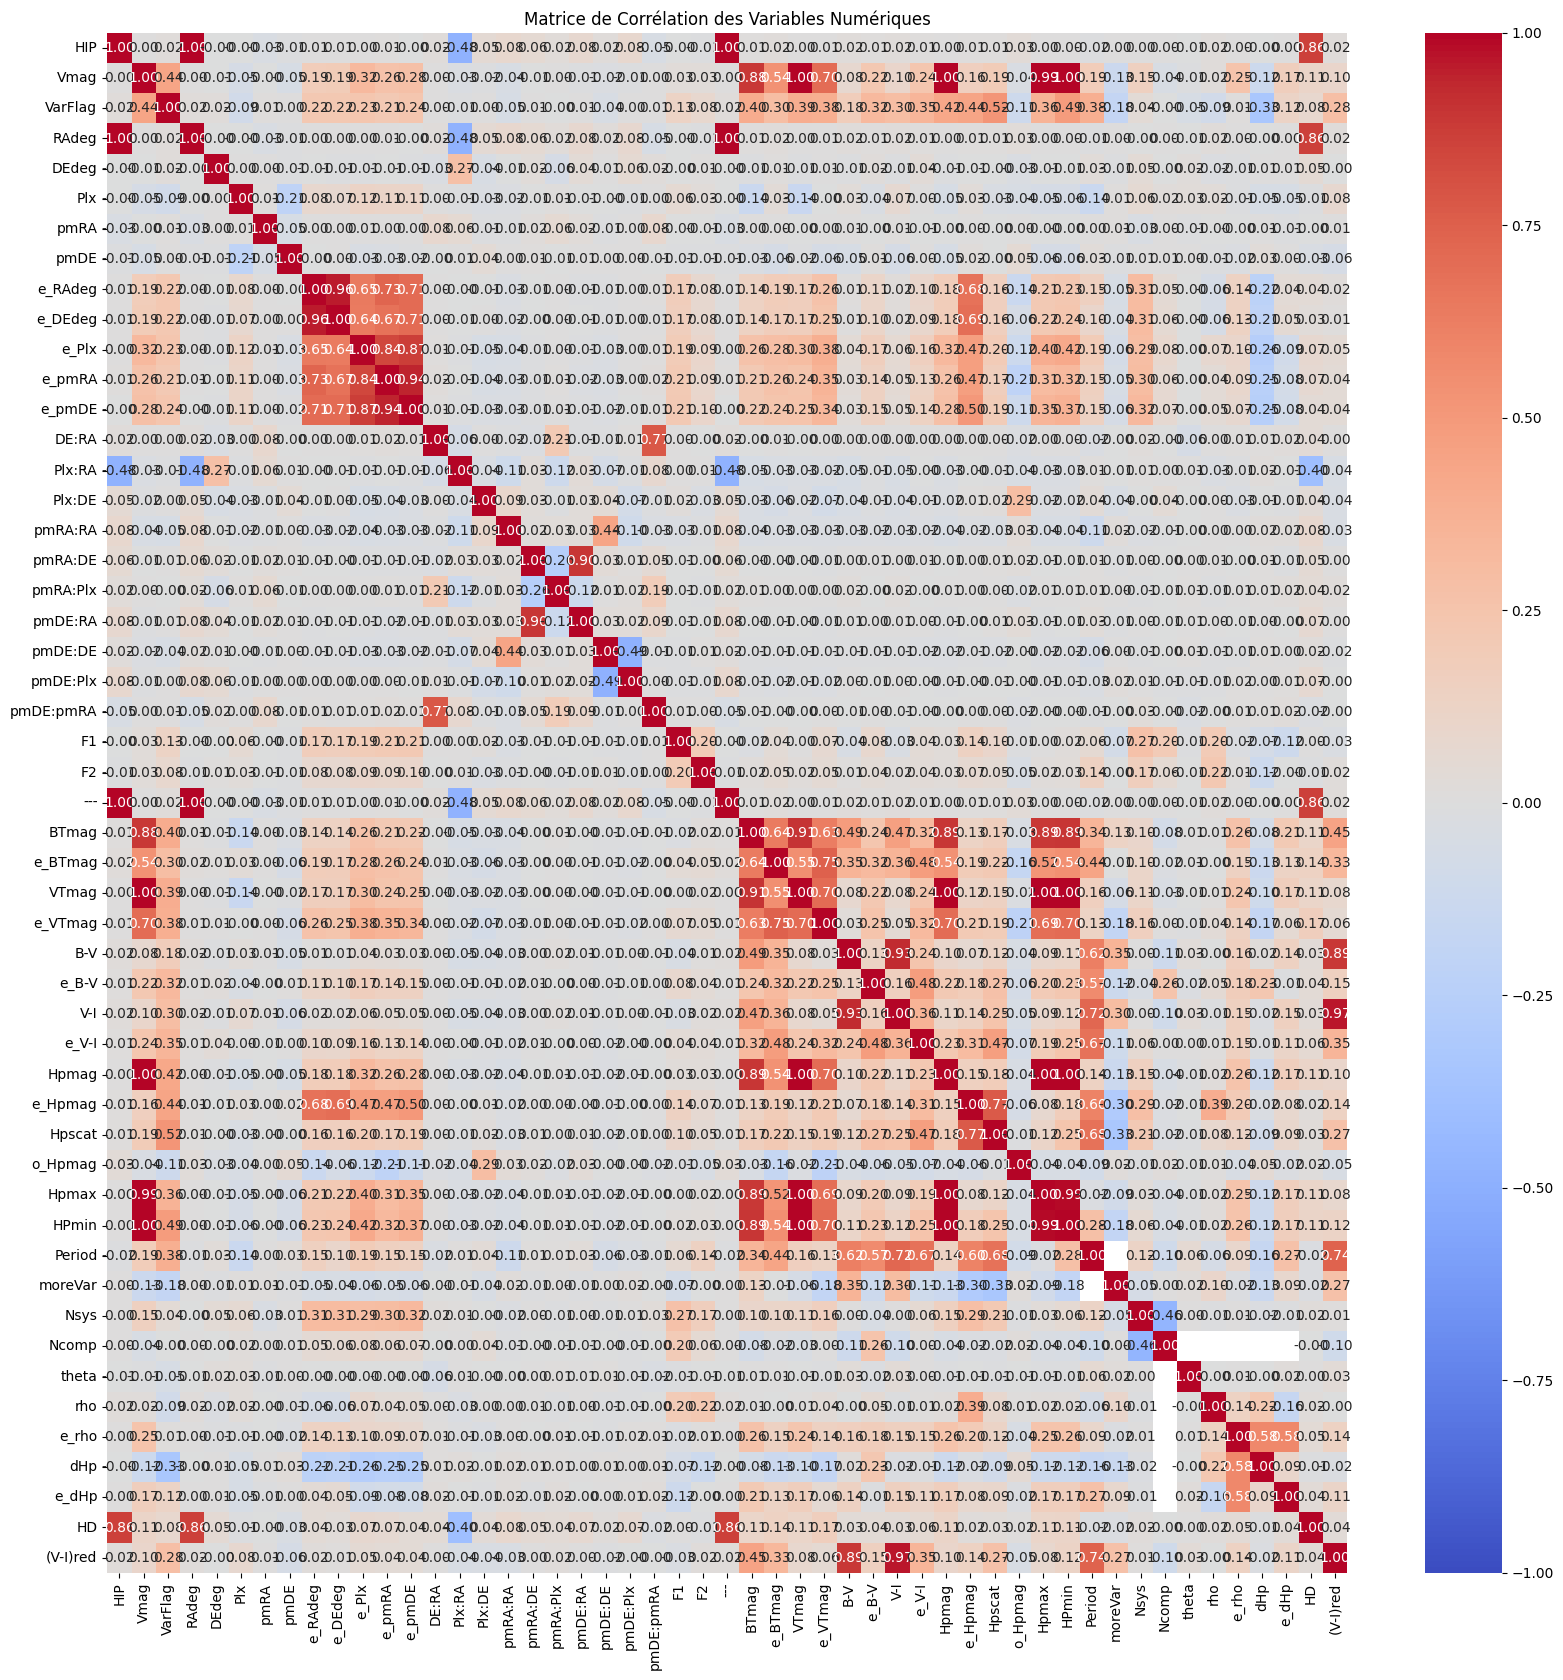

In [100]:
# Extraire seulement les données numériques
num_data = data_true.select_dtypes(include=['number'])

# Matrice de corrélation
corr_matrix = num_data.corr()
print(corr_matrix)

plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title(r"Matrice de Corrélation des Variables Numériques")
plt.show()

           HIP      Vmag       Plx       B-V
HIP   1.000000  0.003751 -0.002868  0.018040
Vmag  0.003751  1.000000 -0.054949  0.076026
Plx  -0.002868 -0.054949  1.000000  0.029421
B-V   0.018040  0.076026  0.029421  1.000000


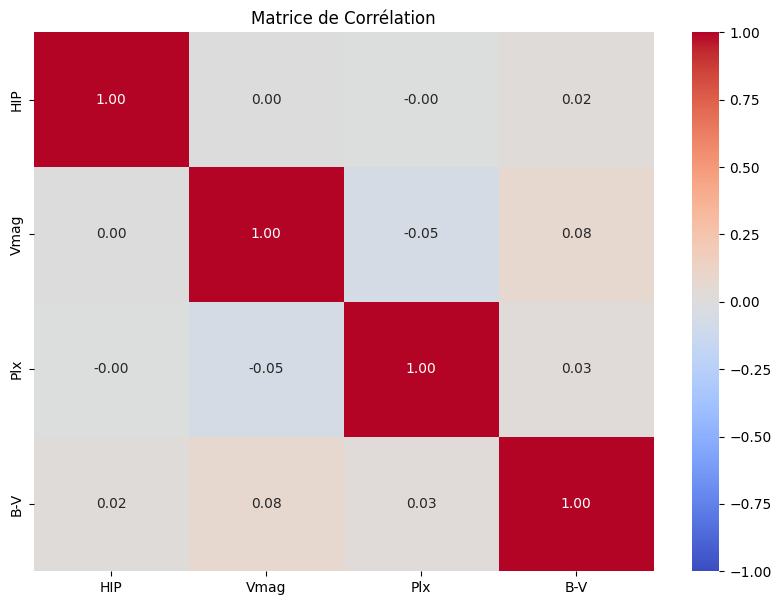

In [101]:
# Extraire quelques données qui semblent être pertinentes (pour une meilleure visualisation)

def matrice_corr(sub_data_name, data) :
    num_data = data.select_dtypes(include=['number'])
    sub_data = num_data[sub_data_name]
    corr_matrix_sub = sub_data.corr()
    print(corr_matrix_sub)

    plt.figure(figsize=(10, 7))
    sns.heatmap(corr_matrix_sub, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
    plt.title("Matrice de Corrélation")
    plt.show()

matrice_corr(['HIP', 'Vmag', 'Plx', 'B-V'], data_true)  



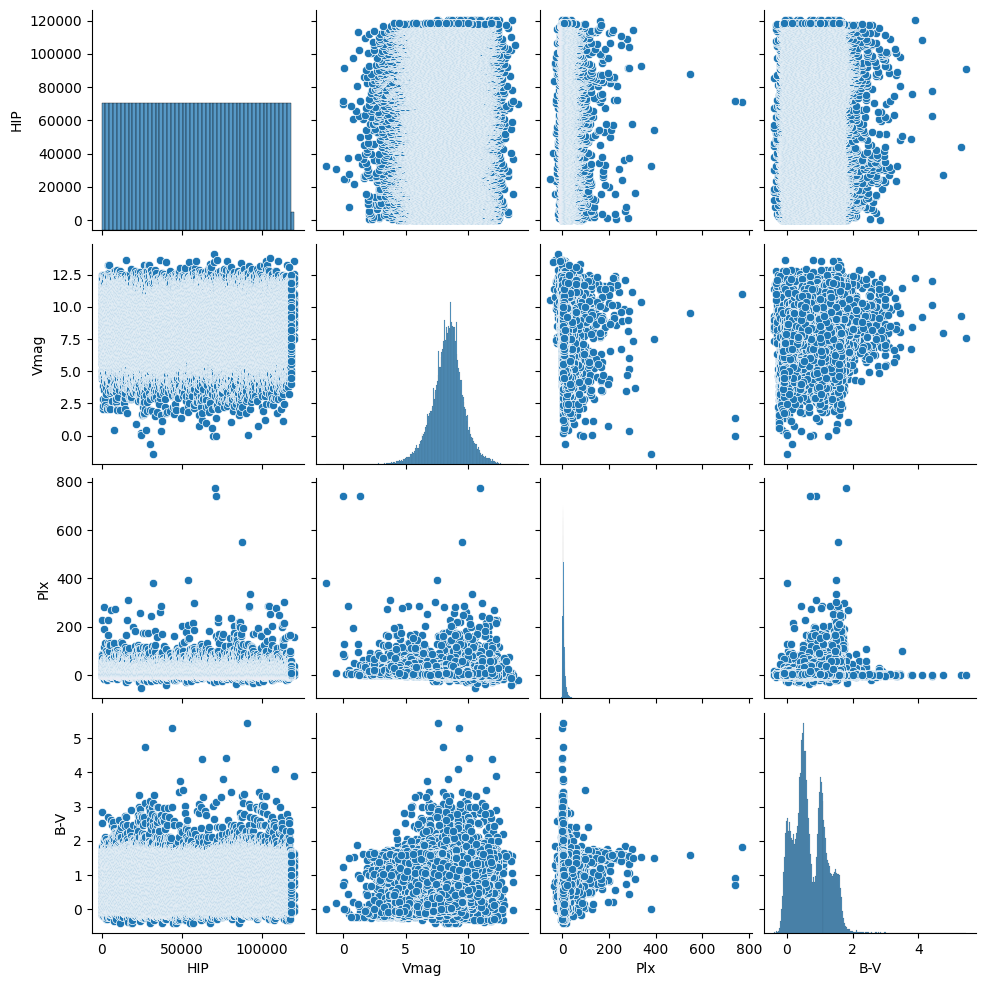

In [102]:
data_sub = data_true[['HIP', 'Vmag', 'Plx', 'B-V']]
sns.pairplot(data=data_sub)  # ?????

### 2.4 - Sélection et créations de variables d'entrainement pertinentes 


In [103]:
# Sélection des variables pertinentes 
data = data_true[['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']]

# Filtrer les étoiles avec une parallaxe positive et significative
data = data[data['Plx'] > 0]

# Calcul de la distance (en pc) 
data['Distance'] = 1/data['Plx'] * 1000  

# Calcul de la magnitude absolue 
data['AbsoluteMag'] = data['Vmag'] - 5 * np.log10(data['Distance'] / 10)   

# Fonction pour calculer la température effective des étoiles
def bv_to_temp(bv):
    return 4600 * ((1 / (0.92 * bv + 1.7)) + (1 / (0.92 * bv + 0.62)))

# Ajouter la température aux données
data['Temperature'] = bv_to_temp(data['B-V'])


Le type spectral est une variable catégorielle qui doit être convertie en une forme utilisable par un algorithme de clustering : 
(O, B, A, F, G, K, M) ---> (1, 2, 3, ...)

In [104]:
# Encodage du type spectral
encoder = LabelEncoder()
data['SpType_encoded'] = encoder.fit_transform(data['SpType'])

# Supression du type spectral 
data = data.drop(columns=['SpType'])

### 2.3 - Traitement des données manquantes

In [105]:
# Vérfifier les valeurs manquantes 
missing_data = data.isnull()
nb_missing_value = missing_data.sum()    # Nombre de valeurs manquantes par colonne
print(nb_missing_value)


HIP                 0
Vmag                0
Plx                 0
B-V               887
Distance            0
AbsoluteMag         0
Temperature       887
SpType_encoded      0
dtype: int64


In [106]:
# Afficher le pourcentage de valeurs manquantes
missing_percent = missing_data.mean() * 100
print(missing_percent)

HIP               0.000000
Vmag              0.000000
Plx               0.000000
B-V               0.780055
Distance          0.000000
AbsoluteMag       0.000000
Temperature       0.780055
SpType_encoded    0.000000
dtype: float64


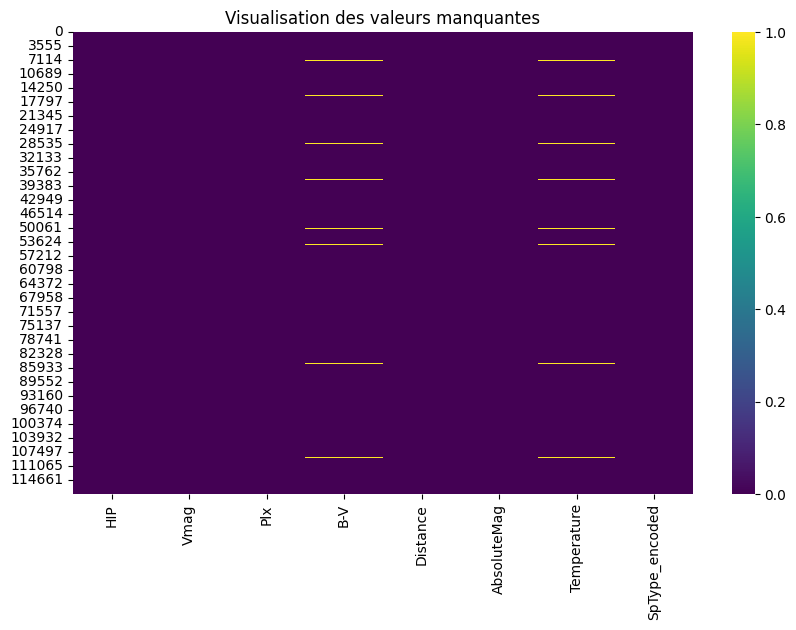

In [107]:
# Heatmap des valeurs manquantes
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cmap="viridis")
plt.title("Visualisation des valeurs manquantes")
plt.show()

In [108]:
# Traiter les valeurs manquantes : comme on a énormément de données, on peut supprimer les lignes avec les valeurs manquantes dans les colonnes pertinentes 
data_clean = data.dropna(subset=['HIP', 'Vmag', 'Plx', 'B-V', 'Distance', 'AbsoluteMag', 'Temperature', 'SpType_encoded'])
print(data_clean.shape)

## Est-ce la meilleure façon ???


(112823, 8)


In [109]:
X = data_clean
X

,HIP,Vmag,Plx,B-V,Distance,AbsoluteMag,Temperature,SpType_encoded
0,1,9.10,3.54,0.482,282.485876,1.845016,6471.667826,1809
1,2,9.27,21.90,0.999,45.662100,5.972221,4745.140425,3178
2,3,6.61,2.81,-0.019,355.871886,-1.146468,10368.595588,1353
3,4,8.06,7.75,0.370,129.032258,2.506509,7044.130880,1604
4,5,8.55,2.87,0.902,348.432056,0.839409,4991.060700,2649
...,...,...,...,...,...,...,...,...
118213,118318,6.99,1.92,1.595,520.833333,-1.593494,3655.993639,3015
118214,118319,8.23,10.63,0.639,94.073377,3.362666,5818.920292,2296
118215,118320,7.59,5.00,0.999,200.000000,1.084850,4745.140425,2768
118216,118321,9.20,19.22,0.698,52.029136,5.618767,5608.544902,2470


### 2.5 - Vérification de nouvelles variables 


                Distance  AbsoluteMag  Temperature  SpType_encoded       B-V
Distance        1.000000     -0.33716    -0.003166        0.015183  0.034706
AbsoluteMag    -0.337160      1.00000    -0.112810        0.120800 -0.054170
Temperature    -0.003166     -0.11281     1.000000       -0.806002 -0.930123
SpType_encoded  0.015183      0.12080    -0.806002        1.000000  0.826801
B-V             0.034706     -0.05417    -0.930123        0.826801  1.000000


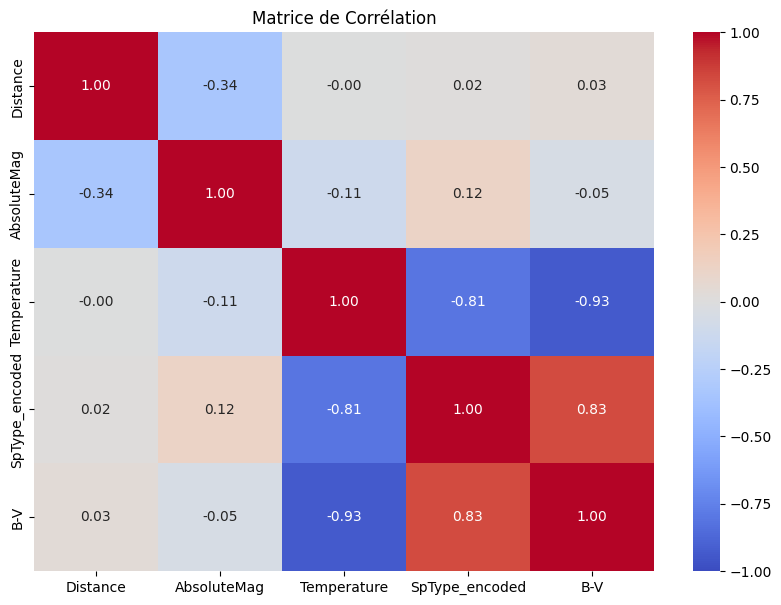

In [110]:
matrice_corr(['Distance', 'AbsoluteMag', 'Temperature', 'SpType_encoded', 'B-V'], data)

### 2.6 - Normalisation des variables d'entrainement 

In [111]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
X_scaled_df

,HIP,Vmag,Plx,B-V,Distance,AbsoluteMag,Temperature,SpType_encoded
0,-1.727453,0.618564,-0.352599,-0.454175,-0.073805,0.074351,0.130850,-0.227177
1,-1.727424,0.751857,1.280499,0.615606,-0.176107,1.801635,-0.713214,1.115105
2,-1.727394,-1.333777,-0.417532,-1.490848,-0.042104,-1.177621,2.035976,-0.674277
3,-1.727365,-0.196871,0.021875,-0.685926,-0.140093,0.351193,0.410715,-0.428176
4,-1.727336,0.187324,-0.412195,0.414893,-0.045318,-0.346508,-0.592988,0.596429
...,...,...,...,...,...,...,...,...
112818,1.731239,-1.035829,-0.496696,1.848854,0.029155,-1.364707,-1.245675,0.955286
112819,1.731268,-0.063579,0.278047,-0.129309,-0.155194,0.709505,-0.188265,0.250319
112820,1.731297,-0.565385,-0.222734,0.615606,-0.109437,-0.243788,-0.713214,0.713107
112821,1.731326,0.696971,1.042117,-0.007226,-0.173356,1.653710,-0.291113,0.420923


In [112]:
## Scaler MinMax
#scaler = MinMaxScaler()
#X_scaled = scaler.fit_transform(X)
#X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
#X_scaled_df
#Does not reduce the effect of outliers

In [113]:
## Robust scaler 
#scaler = RobustScaler()
#X_scaled = scaler.fit_transform(X)
#X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
#X_scaled_df

#scaler = PowerTransformer()
#X_scaled = scaler.fit_transform(X)
#X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
#X_scaled_df

#StandardScaler, 
# MinMaxScaler, mélange des points 
# RobustScaler, score approx 0.9 mais  
# QuantileTransformer, Uniform- no, Normal- forme de cluster se rapproche mais bas score
# Normalizer, mélange des groupes
# MaxAbsScaler, similaire à MinMax
# PowerTransformer, similaire à quantile normal

### 2.7 - Préparation des variables cibles : y en a pas ici car clustering ????

### 2.8 - Séparation du dataset (train/validation/test)

Taille du train : (78976, 8)
Taille du validation : (16923, 8)
Taille du test : (16924, 8)


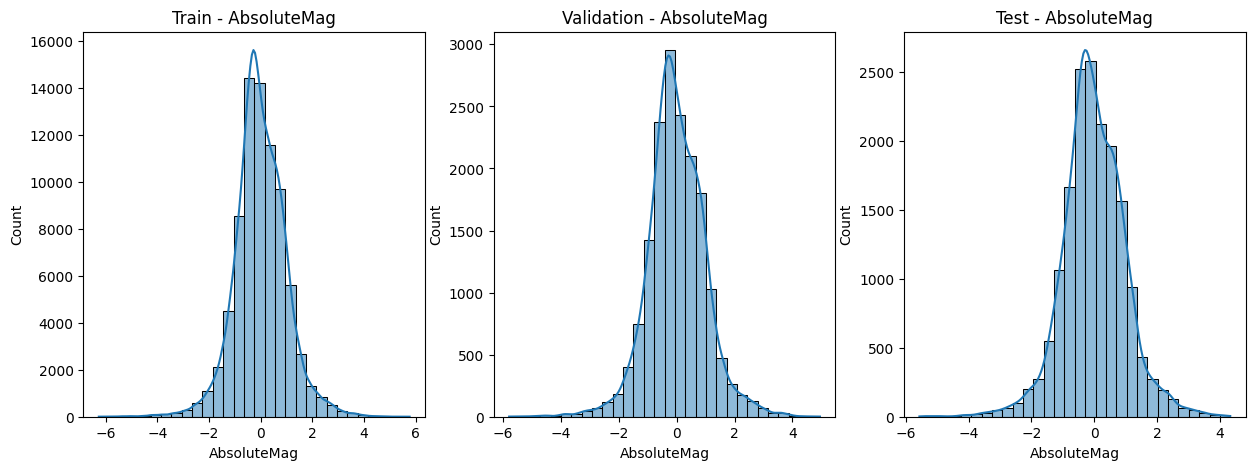

In [114]:
# Séparation en train/validation/test
X_train, X_temp = train_test_split(X_scaled_df, test_size=0.3, random_state=0)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=0)

print(f"Taille du train : {X_train.shape}")
print(f"Taille du validation : {X_val.shape}")
print(f"Taille du test : {X_test.shape}")
#print(X_train)

# Visualiser les données de chaque ensemble (par exemple avec AbsoluteMag)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(X_train['AbsoluteMag'], bins=30, kde=True, ax=axes[0]).set_title("Train - AbsoluteMag")
sns.histplot(X_val['AbsoluteMag'], bins=30, kde=True, ax=axes[1]).set_title("Validation - AbsoluteMag")
sns.histplot(X_test['AbsoluteMag'], bins=30, kde=True, ax=axes[2]).set_title("Test - AbsoluteMag")
plt.show()

## 3) K_Means

### 3.1 - Entrainement 

In [115]:
# On vérifie qu'il n'y pas de valeurs manquantes dans les données
print(X_train.isnull().sum()) 

HIP               0
Vmag              0
Plx               0
B-V               0
Distance          0
AbsoluteMag       0
Temperature       0
SpType_encoded    0
dtype: int64


In [116]:
# Entraînement du modèle k=4
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(X_train)

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=4, random_state=0)

In [117]:
print("Centres des clusters :")
print(kmeans.cluster_centers_) 

Centres des clusters :
[[ 5.03833007e-03 -3.77930781e-01 -2.38101803e-01 -1.16069812e+00
   2.29777759e-02 -4.66867226e-01  1.33216842e+00 -1.33864755e+00]
 [-1.18660616e-02  5.11262725e-01  4.75820434e-01 -1.49885798e-01
  -1.34692551e-01  9.01250115e-01 -1.05336462e-01  1.79081448e-01]
 [ 9.56295308e-03 -2.80600625e-01 -3.43667632e-01  1.05782597e+00
   6.87410473e-02 -6.31922325e-01 -9.07371729e-01  8.28790748e-01]
 [ 1.31101326e-01  4.38529090e-01 -6.66109356e-01  3.28980659e-01
   3.13714876e+01 -5.01649714e+00 -1.00256477e-01  3.48102979e-01]]


In [118]:
# Prédire les clusters pour l'ensemble d'entraînement
train_clusters = kmeans.predict(X_train)

# Ajouter les clusters comme une nouvelle colonne dans X_train
X_train['Cluster'] = train_clusters

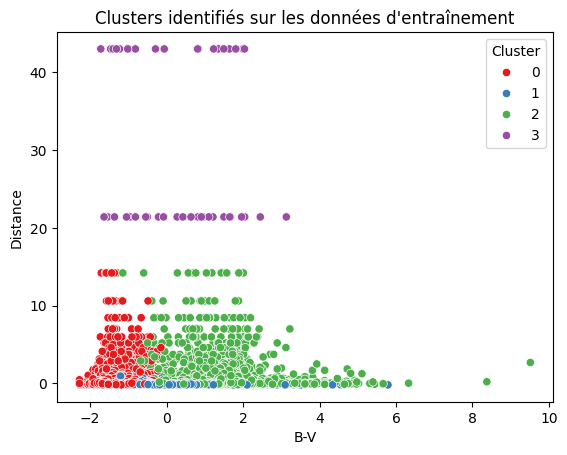

In [119]:
sns.scatterplot(x=X_train['B-V'], y=X_train['Distance'], hue=X_train['Cluster'], palette="Set1")
plt.title("Clusters identifiés sur les données d'entraînement")
plt.show()


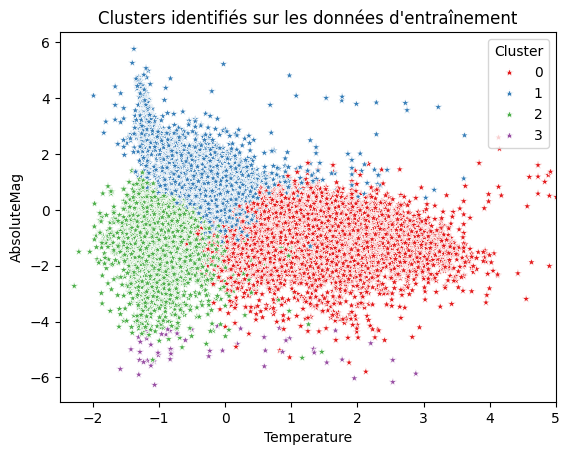

In [120]:
sns.scatterplot(x=X_train['Temperature'], y=X_train['AbsoluteMag'], hue=X_train['Cluster'], palette="Set1", marker="*")   
plt.title("Clusters identifiés sur les données d'entraînement")
plt.xlim(-2.5, 5)
#plt.gca().invert_yaxis()  # il faut inverser l'axe de AbsoluteMag par convention du diagramme HR
plt.show()



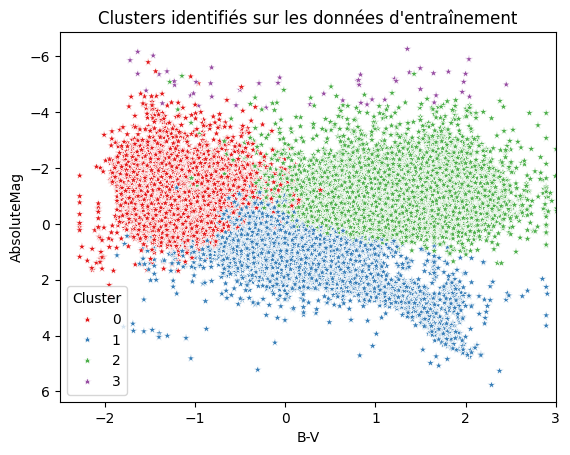

In [121]:
sns.scatterplot(x=X_train['B-V'], y=X_train['AbsoluteMag'], hue=X_train['Cluster'], palette="Set1", marker="*")   
plt.title("Clusters identifiés sur les données d'entraînement")
plt.xlim(-2.5, 3)
plt.gca().invert_yaxis()  # il faut inverser l'axe de AbsoluteMag par convention du diagramme HR
plt.show()

# bon graphe mais pas bons clusters 
# pb on ne voit pas distinctement les clusters : faire pca avec 2 ou 3 comp

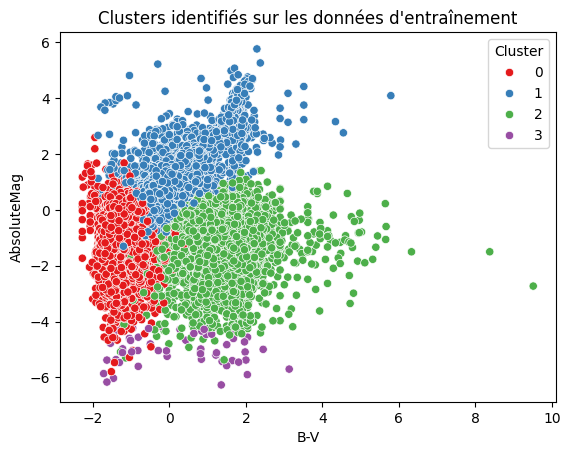

In [122]:
sns.scatterplot(x=X_train['B-V'], y=X_train['AbsoluteMag'], hue=X_train['Cluster'], palette="Set1")
plt.title("Clusters identifiés sur les données d'entraînement")
plt.show()

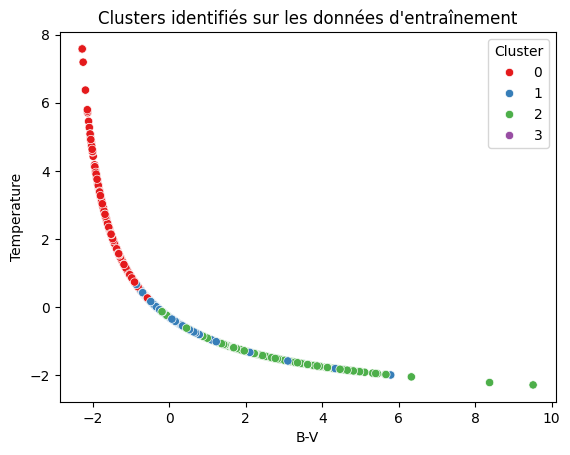

In [123]:
sns.scatterplot(x=X_train['B-V'], y=X_train['Temperature'], hue=X_train['Cluster'], palette="Set1")
plt.title("Clusters identifiés sur les données d'entraînement")
plt.show()

### 3.2 - Évaluation du modèle

### 

In [124]:
# Evaluer la qualité des clusters : Le silhouette score mesure à quel point chaque point est bien classé dans son cluster comparé aux autres clusters.
score = silhouette_score(X_train, kmeans.labels_) 
print("Silhouette Score :", score)

# Si la valeur est proche de 1 alors on a un meilleur clustering




Silhouette Score : 0.3271303353732868


In [125]:
#samples = silhouette_samples(X_train, kmeans.labels_)
#plt.bar(range(len(samples)), samples)
#plt.title("Silhouette Coefficient for each point")
#plt.xlabel("Point index")
#plt.ylabel("Silhouette score")
#plt.show()

### 3.3 - PCA

In [126]:
data_true


,Catalog,HIP,Proxy,RAhms,DEdms,Vmag,VarFlag,r_Vmag,RAdeg,DEdeg,...,Survey,Chart,Notes,HD,BD,CoD,CPD,(V-I)red,SpType,r_SpType
0,H,1,NaN,00 00 00.22,+01 05 20.4,9.10,NaN,H,0.000912,1.089013,...,S,NaN,NaN,224700.0,B+00 5077,NaN,NaN,0.66,F5,S
1,H,2,NaN,00 00 00.91,-19 29 55.8,9.27,NaN,G,0.003797,-19.498837,...,NaN,NaN,NaN,224690.0,B-20 6688,NaN,NaN,1.04,K3V,4
2,H,3,NaN,00 00 01.20,+38 51 33.4,6.61,NaN,G,0.005008,38.859286,...,S,NaN,NaN,224699.0,B+38 5108,NaN,NaN,0.00,B9,S
3,H,4,NaN,00 00 02.01,-51 53 36.8,8.06,NaN,H,0.008382,-51.893546,...,S,NaN,NaN,224707.0,NaN,NaN,P-52 12237,0.43,F0V,2
4,H,5,NaN,00 00 02.39,-40 35 28.4,8.55,NaN,H,0.009965,-40.591224,...,NaN,NaN,NaN,224705.0,NaN,C-41 15372,P-41 9991,0.95,G8III,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,H,118318,NaN,23 59 51.30,+11 40 25.4,6.99,1.0,H,359.963744,11.673709,...,S,NaN,NaN,224673.0,B+10 5018,NaN,NaN,1.56,K2,S
118214,H,118319,NaN,23 59 53.74,-22 25 41.4,8.23,NaN,G,359.973913,-22.428180,...,S,NaN,NaN,224693.0,NaN,C-23 18108,P-23 8366,0.70,G2V,4
118215,H,118320,NaN,23 59 54.25,+05 57 23.9,7.59,NaN,H,359.976057,5.956638,...,S,NaN,NaN,224689.0,B+05 5245,NaN,NaN,0.98,K0,S
118216,H,118321,NaN,23 59 54.78,-64 22 21.3,9.20,NaN,G,359.978239,-64.372572,...,NaN,NaN,NaN,224685.0,NaN,C-65 2958,P-65 4188,0.75,G5V,1


In [127]:
total_rows = len(data_true)
for col, val in nb_missing_value.items():
    if val > 0:
        percent = (val / total_rows) * 100
        print(f"{col} : {val} NaNs ({percent:.2f}%)")


B-V : 887 NaNs (0.75%)
Temperature : 887 NaNs (0.75%)


Colonnes inutiles : 
- Catalog
- HIP
- Proxy
- VarFlag
- AstroRef
- m_BTmag
- CombMag
- m_Hpmag
- Period
- HvarType
- moreVar
- morePhoto
- CCDM
- n_CCDM
- Nsys
- MultFlag
- Source
- Qual
- m_HIP
- theta
- rho
- e_rho
- dHp
- e_dHp
- Survey
- Chart
- Notes
- HD
- BD
- CoD
- CPD


In [128]:
colonnes_inutiles = [
    "Catalog", "Proxy", "VarFlag", "AstroRef", "m_BTmag", "CombMag",
    "m_Hpmag", "Period", "HvarType", "moreVar", "morePhoto", "CCDM", "n_CCDM",
    "Nsys", "MultFlag", "Source", "Qual", "m_HIP", "theta", "rho", "e_rho",
    "dHp", "e_dHp", "Survey", "Chart", "Notes", "HD", "BD", "CoD", "CPD"
]
data_pca = data_true.drop(columns=colonnes_inutiles)
data_pca

,HIP,RAhms,DEdms,Vmag,r_Vmag,RAdeg,DEdeg,Plx,pmRA,pmDE,...,Hpmag,e_Hpmag,Hpscat,o_Hpmag,Hpmax,HPmin,Ncomp,(V-I)red,SpType,r_SpType
0,1,00 00 00.22,+01 05 20.4,9.10,H,0.000912,1.089013,3.54,-5.20,-1.88,...,9.2043,0.0020,0.017,87.0,9.17,9.24,1.0,0.66,F5,S
1,2,00 00 00.91,-19 29 55.8,9.27,G,0.003797,-19.498837,21.90,181.21,-0.93,...,9.4017,0.0017,0.015,120.0,9.37,9.44,1.0,1.04,K3V,4
2,3,00 00 01.20,+38 51 33.4,6.61,G,0.005008,38.859286,2.81,5.24,-2.91,...,6.6081,0.0007,0.008,127.0,6.60,6.62,1.0,0.00,B9,S
3,4,00 00 02.01,-51 53 36.8,8.06,H,0.008382,-51.893546,7.75,62.85,0.16,...,8.1498,0.0011,0.015,201.0,8.12,8.18,1.0,0.43,F0V,2
4,5,00 00 02.39,-40 35 28.4,8.55,H,0.009965,-40.591224,2.87,2.53,9.07,...,8.7077,0.0018,0.019,161.0,8.68,8.74,1.0,0.95,G8III,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,118318,23 59 51.30,+11 40 25.4,6.99,H,359.963744,11.673709,1.92,-2.16,2.09,...,7.1043,0.0018,0.014,92.0,7.08,7.12,1.0,1.56,K2,S
118214,118319,23 59 53.74,-22 25 41.4,8.23,G,359.973913,-22.428180,10.63,148.74,27.53,...,8.3699,0.0014,0.016,118.0,8.34,8.39,1.0,0.70,G2V,4
118215,118320,23 59 54.25,+05 57 23.9,7.59,H,359.976057,5.956638,5.00,20.92,-35.26,...,7.7604,0.0010,0.010,86.0,7.74,7.77,1.0,0.98,K0,S
118216,118321,23 59 54.78,-64 22 21.3,9.20,G,359.978239,-64.372572,19.22,216.99,106.46,...,9.3312,0.0019,0.022,145.0,9.28,9.36,1.0,0.75,G5V,1


In [129]:
data_clean_pca = data_pca.dropna(axis=0)
print(data_clean_pca.shape)


(111171, 48)


In [130]:
print(data_clean_pca.dtypes)

HIP            int64
RAhms         object
DEdms         object
Vmag         float64
r_Vmag        object
RAdeg        float64
DEdeg        float64
Plx          float64
pmRA         float64
pmDE         float64
e_RAdeg      float64
e_DEdeg      float64
e_Plx        float64
e_pmRA       float64
e_pmDE       float64
DE:RA        float64
Plx:RA       float64
Plx:DE       float64
pmRA:RA      float64
pmRA:DE      float64
pmRA:Plx     float64
pmDE:RA      float64
pmDE:DE      float64
pmDE:Plx     float64
pmDE:pmRA    float64
F1           float64
F2           float64
---            int64
BTmag        float64
e_BTmag      float64
VTmag        float64
e_VTmag      float64
B-V          float64
e_B-V        float64
r_B-V         object
V-I          float64
e_V-I        float64
r_V-I         object
Hpmag        float64
e_Hpmag      float64
Hpscat       float64
o_Hpmag      float64
Hpmax        float64
HPmin        float64
Ncomp        float64
(V-I)red     float64
SpType        object
r_SpType     

In [131]:
non_float_cols = data_clean_pca.select_dtypes(exclude=['float']).columns
print(non_float_cols)

print(data_clean_pca['---'])

Index(['HIP', 'RAhms', 'DEdms', 'r_Vmag', '---', 'r_B-V', 'r_V-I', 'SpType',
       'r_SpType'],
      dtype='object')
0              1
1              2
2              3
3              4
4              5
           ...  
118213    118318
118214    118319
118215    118320
118216    118321
118217    118322
Name: ---, Length: 111171, dtype: int64


In [132]:
data_clean_pca_2 = data_clean_pca.drop(columns='---')
print(data_clean_pca_2.dtypes)
data_clean_pca_2


HIP            int64
RAhms         object
DEdms         object
Vmag         float64
r_Vmag        object
RAdeg        float64
DEdeg        float64
Plx          float64
pmRA         float64
pmDE         float64
e_RAdeg      float64
e_DEdeg      float64
e_Plx        float64
e_pmRA       float64
e_pmDE       float64
DE:RA        float64
Plx:RA       float64
Plx:DE       float64
pmRA:RA      float64
pmRA:DE      float64
pmRA:Plx     float64
pmDE:RA      float64
pmDE:DE      float64
pmDE:Plx     float64
pmDE:pmRA    float64
F1           float64
F2           float64
BTmag        float64
e_BTmag      float64
VTmag        float64
e_VTmag      float64
B-V          float64
e_B-V        float64
r_B-V         object
V-I          float64
e_V-I        float64
r_V-I         object
Hpmag        float64
e_Hpmag      float64
Hpscat       float64
o_Hpmag      float64
Hpmax        float64
HPmin        float64
Ncomp        float64
(V-I)red     float64
SpType        object
r_SpType      object
dtype: object

,HIP,RAhms,DEdms,Vmag,r_Vmag,RAdeg,DEdeg,Plx,pmRA,pmDE,...,Hpmag,e_Hpmag,Hpscat,o_Hpmag,Hpmax,HPmin,Ncomp,(V-I)red,SpType,r_SpType
0,1,00 00 00.22,+01 05 20.4,9.10,H,0.000912,1.089013,3.54,-5.20,-1.88,...,9.2043,0.0020,0.017,87.0,9.17,9.24,1.0,0.66,F5,S
1,2,00 00 00.91,-19 29 55.8,9.27,G,0.003797,-19.498837,21.90,181.21,-0.93,...,9.4017,0.0017,0.015,120.0,9.37,9.44,1.0,1.04,K3V,4
2,3,00 00 01.20,+38 51 33.4,6.61,G,0.005008,38.859286,2.81,5.24,-2.91,...,6.6081,0.0007,0.008,127.0,6.60,6.62,1.0,0.00,B9,S
3,4,00 00 02.01,-51 53 36.8,8.06,H,0.008382,-51.893546,7.75,62.85,0.16,...,8.1498,0.0011,0.015,201.0,8.12,8.18,1.0,0.43,F0V,2
4,5,00 00 02.39,-40 35 28.4,8.55,H,0.009965,-40.591224,2.87,2.53,9.07,...,8.7077,0.0018,0.019,161.0,8.68,8.74,1.0,0.95,G8III,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,118318,23 59 51.30,+11 40 25.4,6.99,H,359.963744,11.673709,1.92,-2.16,2.09,...,7.1043,0.0018,0.014,92.0,7.08,7.12,1.0,1.56,K2,S
118214,118319,23 59 53.74,-22 25 41.4,8.23,G,359.973913,-22.428180,10.63,148.74,27.53,...,8.3699,0.0014,0.016,118.0,8.34,8.39,1.0,0.70,G2V,4
118215,118320,23 59 54.25,+05 57 23.9,7.59,H,359.976057,5.956638,5.00,20.92,-35.26,...,7.7604,0.0010,0.010,86.0,7.74,7.77,1.0,0.98,K0,S
118216,118321,23 59 54.78,-64 22 21.3,9.20,G,359.978239,-64.372572,19.22,216.99,106.46,...,9.3312,0.0019,0.022,145.0,9.28,9.36,1.0,0.75,G5V,1


In [133]:
cols_encoder = ["RAhms", "DEdms", "r_Vmag", "r_B-V", "r_V-I", "SpType", "r_SpType"]
label_encoders = {}

for col in cols_encoder:
    if col in data_clean_pca_2.columns:
        le = LabelEncoder()
        data_clean_pca_2[col] = le.fit_transform(data_clean_pca_2[col].astype(str))
        label_encoders[col] = le
    else:
        print(f"Colonne '{col}' non trouvée dans le DataFrame")

data_clean_pca_2
print(data_clean_pca_2.dtypes)

HIP            int64
RAhms          int64
DEdms          int64
Vmag         float64
r_Vmag         int64
RAdeg        float64
DEdeg        float64
Plx          float64
pmRA         float64
pmDE         float64
e_RAdeg      float64
e_DEdeg      float64
e_Plx        float64
e_pmRA       float64
e_pmDE       float64
DE:RA        float64
Plx:RA       float64
Plx:DE       float64
pmRA:RA      float64
pmRA:DE      float64
pmRA:Plx     float64
pmDE:RA      float64
pmDE:DE      float64
pmDE:Plx     float64
pmDE:pmRA    float64
F1           float64
F2           float64
BTmag        float64
e_BTmag      float64
VTmag        float64
e_VTmag      float64
B-V          float64
e_B-V        float64
r_B-V          int64
V-I          float64
e_V-I        float64
r_V-I          int64
Hpmag        float64
e_Hpmag      float64
Hpscat       float64
o_Hpmag      float64
Hpmax        float64
HPmin        float64
Ncomp        float64
(V-I)red     float64
SpType         int64
r_SpType       int64
dtype: object

In [134]:


# Étape 2 : extraire HIP seulement après
hip_array = data_clean_pca_2['HIP'].values

# Étape 3 : retirer HIP pour la PCA
data_pca_ready = data_clean_pca_2.drop(columns='HIP')


In [135]:
pca = decomposition.PCA(n_components=2) # 2 pour garder 2 composantes
pca.fit(data_pca_ready)
#print("Avant : (les 10 premiers éléments seuls)\n", data_clean_pca_2[:10,:])

data_t = pca.transform(data_pca_ready)
print("Dimension de data_t :", data_t.shape)
print("Après : (les 10 premiers éléments seult)\n", data_t[:10,:])

data_t_df = pd.DataFrame(data_t, columns=['Col1', 'Col2'])


Dimension de data_t : (111171, 2)
Après : (les 10 premiers éléments seult)
 [[ 63660.2826088  -43849.56789272]
 [ 52109.02003654  22593.04087708]
 [ 58407.18010779 -13640.77207783]
 [ 47493.005094    49138.9979123 ]
 [ 49132.56990137  39699.12651834]
 [ 60991.14493994 -28524.77034008]
 [ 60167.53661035 -23795.40850464]
 [ 58705.76561979 -15389.69104805]
 [ 47632.24792239  48308.13229593]
 [ 57337.86859929  -7527.74414418]]


In [136]:
# Séparation en train/validation/test
X_train, X_temp = train_test_split(data_t_df, test_size=0.3, random_state=0)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=0)

print(f"Taille du train : {X_train.shape}")
print(f"Taille du validation : {X_val.shape}")
print(f"Taille du test : {X_test.shape}")
print(type(X_train))

Taille du train : (77819, 2)
Taille du validation : (16676, 2)
Taille du test : (16676, 2)
<class 'pandas.core.frame.DataFrame'>


In [137]:
print(X_train.isnull().sum())

Col1    0
Col2    0
dtype: int64


In [ ]:
# Entraînement du modèle k=4
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(X_train)

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=4, random_state=0)

In [ ]:
print("Centres des clusters :")
print(kmeans.cluster_centers_) 
cluster_labels = kmeans.labels_

Centres des clusters :
[[ 0.79736419 -0.59238339 -0.2821698  -0.11486851]
 [-0.97646933 -0.04095773  0.98444738 -0.02472843]
 [-0.51516535  0.60406842 -1.14973696  0.10147836]
 [ 2.78595106  1.42776843  0.86792813  0.43868286]]


In [ ]:
# Prédire les clusters pour l'ensemble d'entraînement
train_clusters = kmeans.predict(X_train)

# Ajouter les clusters comme une nouvelle colonne dans X_train
X_train['Cluster'] = train_clusters

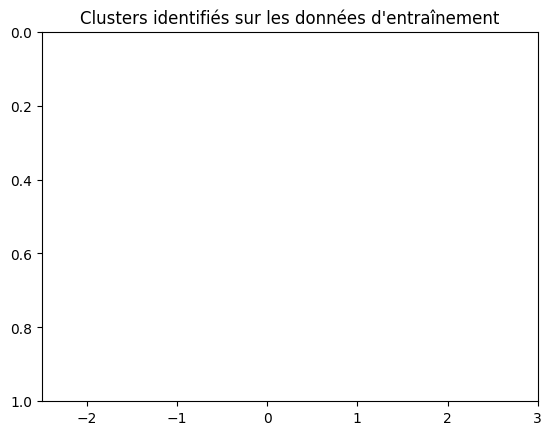

In [ ]:
# Filtrer les étoiles avec une parallaxe positive et significative
data_clean_pca_2 = data_clean_pca_2[data_clean_pca_2['Plx'] > 0]

# Calcul de la distance (en pc) 
data_clean_pca_2['Distance'] = 1/data_clean_pca_2['Plx'] * 1000  

# Calcul de la magnitude absolue 
data_clean_pca_2['AbsoluteMag'] = data_clean_pca_2['Vmag'] - 5 * np.log10(data_clean_pca_2['Distance'] / 10)   

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_clean_pca_2)
X_scaled_df = pd.DataFrame(X_scaled, columns = data_clean_pca_2.columns)

filtered_data = X_scaled_df[X_scaled_df['HIP'].isin(hip_array)]

sns.scatterplot(x=filtered_data['B-V'], y=filtered_data['AbsoluteMag'], hue=cluster_labels, palette="Set1", marker="*")   
plt.title("Clusters identifiés sur les données d'entraînement")
plt.xlim(-2.5, 3)
plt.gca().invert_yaxis()  # il faut inverser l'axe de AbsoluteMag par convention du diagramme HR
plt.show()


## 4) DBSCAN

### 4.1 - Entrainement 

In [ ]:
dbscan = DBSCAN(eps=0.6, min_samples=5)
dbscan.fit(X_train)

DBSCAN(eps=0.6)

In [ ]:
# Prédire les clusters pour l'ensemble d'entraînement
train_clusters_dbscan = dbscan.fit_predict(X_train)

# Ajouter les clusters comme une nouvelle colonne dans X_train
X_train['Cluster'] = train_clusters_dbscan

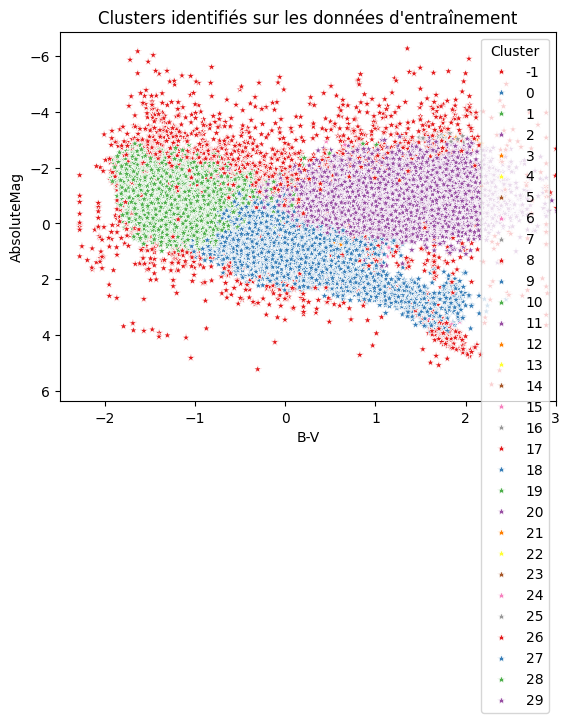

In [ ]:
sns.scatterplot(x=X_train['B-V'], y=X_train['AbsoluteMag'], hue=X_train['Cluster'], palette="Set1", marker="*")   
plt.title("Clusters identifiés sur les données d'entraînement")
plt.xlim(-2.5, 3)
plt.gca().invert_yaxis()  
plt.show()